## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('SouthGermanCredit.asc', sep=r'\s+')
print(dataset.head(10))

   laufkont  laufzeit  moral  verw  hoehe  sparkont  beszeit  rate  famges  \
0         1        18      4     2   1049         1        2     4       2   
1         1         9      4     0   2799         1        3     2       3   
2         2        12      2     9    841         2        4     2       2   
3         1        12      4     0   2122         1        3     3       3   
4         1        12      4     0   2171         1        3     4       3   
5         1        10      4     0   2241         1        2     1       3   
6         1         8      4     0   3398         1        4     1       3   
7         1         6      4     0   1361         1        2     2       3   
8         4        18      4     3   1098         1        1     4       2   
9         2        24      2     3   3758         3        1     1       2   

   buerge  ...  verm  alter  weitkred  wohn  bishkred  beruf  pers  telef  \
0       1  ...     2     21         3     1         1      3    

## Importing the dataset

In [3]:
dataset.rename(columns={
    'laufkont': 'checking_account',
    'laufzeit': 'duration',
    'moral': 'credit_history',
    'verw': 'purpose',
    'hoehe': 'credit_amount',
    'sparkont': 'savings_account',
    'beszeit': 'employment_duration',
    'rate': 'installment_rate',
    'famges': 'personal_status_sex',
    'buerge': 'guarantor',
    'wohnzeit': 'residence_duration',
    'verm': 'property',
    'alter': 'age',
    'weitkred': 'other_installment_plans',
    'wohn': 'housing',
    'bishkred': 'existing_credits',
    'beruf': 'job',
    'pers': 'dependents',
    'telef': 'telephone',
    'gastarb': 'foreign_worker',
    'kredit': 'credit_risk'
}, inplace=True)


print(dataset.head(10))

   checking_account  duration  credit_history  purpose  credit_amount  \
0                 1        18               4        2           1049   
1                 1         9               4        0           2799   
2                 2        12               2        9            841   
3                 1        12               4        0           2122   
4                 1        12               4        0           2171   
5                 1        10               4        0           2241   
6                 1         8               4        0           3398   
7                 1         6               4        0           1361   
8                 4        18               4        3           1098   
9                 2        24               2        3           3758   

   savings_account  employment_duration  installment_rate  \
0                1                    2                 4   
1                1                    3                 2   
2            

In [4]:
missing_data = dataset.isnull().sum()
print(missing_data)

checking_account           0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_duration        0
installment_rate           0
personal_status_sex        0
guarantor                  0
residence_duration         0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
dependents                 0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64


In [5]:
print(dataset.nunique())

checking_account             4
duration                    33
credit_history               5
purpose                     10
credit_amount              923
savings_account              5
employment_duration          5
installment_rate             4
personal_status_sex          4
guarantor                    3
residence_duration           4
property                     4
age                         53
other_installment_plans      3
housing                      3
existing_credits             4
job                          4
dependents                   2
telephone                    2
foreign_worker               2
credit_risk                  2
dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print(dataset.corr()['credit_amount'].sort_values())

installment_rate          -0.271322
credit_risk               -0.154740
other_installment_plans   -0.069392
credit_history            -0.059915
checking_account          -0.042695
guarantor                 -0.027831
dependents                -0.017144
personal_status_sex       -0.016094
employment_duration       -0.008376
existing_credits           0.020785
residence_duration         0.028917
foreign_worker             0.030662
age                        0.032273
savings_account            0.064632
purpose                    0.068480
housing                    0.133024
telephone                  0.277000
job                        0.285393
property                   0.311602
duration                   0.624988
credit_amount              1.000000
Name: credit_amount, dtype: float64


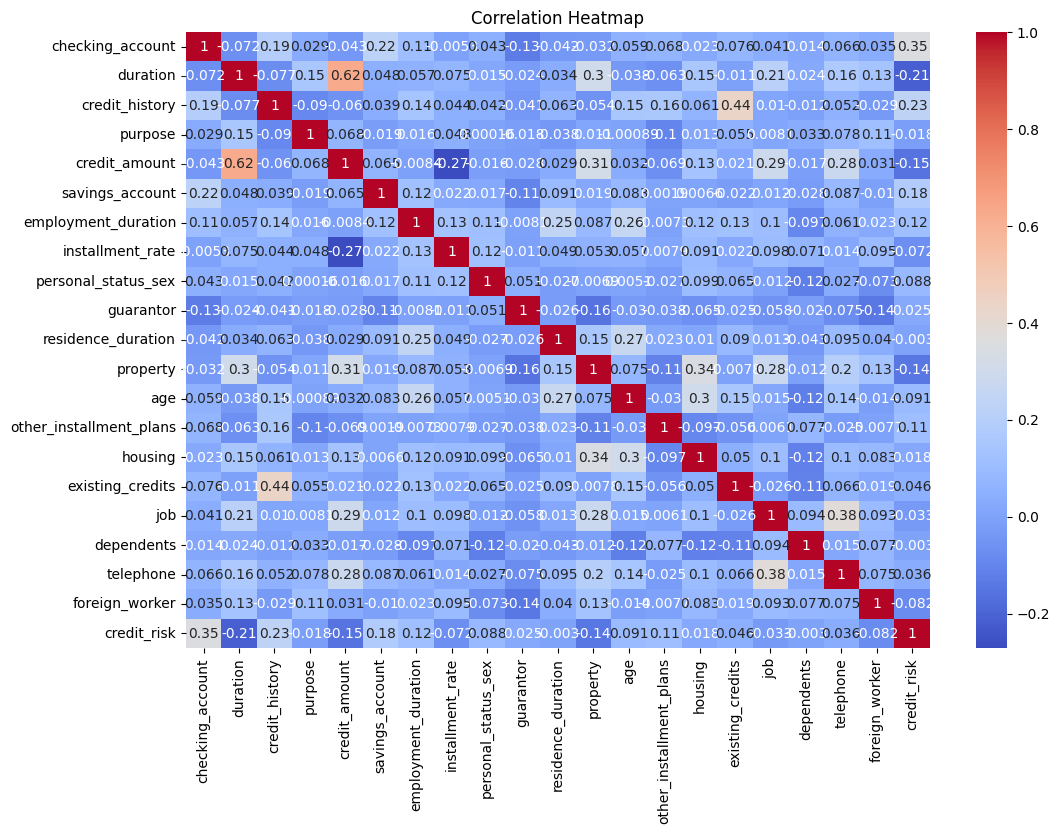

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.corr(),annot=True,cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [8]:
x= dataset[
['duration',
'property',
'job',
'telephone',
'housing',
'purpose',
'savings_account',
'age',
'installment_rate'
]].values

y = dataset['credit_amount'].values


In [9]:
from sklearn.compose  import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[4,5])],remainder = 'passthrough')
x=np.array(ct.fit_transform(x))
print(x)

[[ 1.  0.  0. ...  1. 21.  4.]
 [ 1.  0.  0. ...  1. 36.  2.]
 [ 1.  0.  0. ...  2. 23.  2.]
 ...
 [ 0.  0.  1. ...  5. 30.  4.]
 [ 0.  1.  0. ...  5. 52.  2.]
 [ 0.  1.  0. ...  5. 31.  4.]]


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [11]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [12]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 2039.  3966.]
 [ 1471.   727.]
 [ 1567.   983.]
 [ 2390.   894.]
 [  866.  1113.]
 [ 5103.  8318.]
 [ 2118.  1154.]
 [  368.   426.]
 [ 3448.  1374.]
 [  929.  3617.]
 [ 1740.  2108.]
 [ 2603.  5433.]
 [  802.  2149.]
 [ 9629.  2569.]
 [ 9857.  4281.]
 [ 1092.   385.]
 [ 1131.  1553.]
 [ 2578.  3235.]
 [ 8471.  1936.]
 [  571.  1940.]
 [ 1842.  3535.]
 [ 1925.  3001.]
 [ 2073.   930.]
 [ 9629.  2751.]
 [ 2631.  1264.]
 [ 3021.  4241.]
 [ 1602.  1216.]
 [10875.  7432.]
 [ 3566.  3060.]
 [ 3518.  2799.]
 [ 3190.  1835.]
 [ 2032.  3757.]
 [ 2760.  6579.]
 [ 2327.  1778.]
 [ 1275.  1913.]
 [  802.  1082.]
 [ 6568.  3441.]
 [ 4006.  1258.]
 [ 8335.  4605.]
 [ 3079.   909.]
 [ 1880.  1278.]
 [ 1249.  2303.]
 [ 3069.  3149.]
 [ 5800.  4576.]
 [ 1928.  6204.]
 [  448.   433.]
 [ 1740.  1980.]
 [ 3074.  3832.]
 [ 2439.  1559.]
 [ 9857.  3620.]
 [ 3749.  2404.]
 [ 9857.  8133.]
 [ 1289.  1275.]
 [ 2631.  2326.]
 [ 3573.  1534.]
 [ 2896.  3621.]
 [ 2301.   660.]
 [ 1413.  1236.]
 [  886.   674

In [13]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

-0.1847929571940039

## Training the Random Forest Regression model on the whole dataset


In [14]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, random_state=0)

In [15]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 3447.   3966. ]
 [ 1742.1   727. ]
 [ 2659.1   983. ]
 [ 1684.4   894. ]
 [ 1139.1  1113. ]
 [ 5770.9  8318. ]
 [ 2260.4  1154. ]
 [  752.1   426. ]
 [ 2330.3  1374. ]
 [ 2472.6  3617. ]
 [ 1808.6  2108. ]
 [ 6814.   5433. ]
 [ 2174.   2149. ]
 [ 6727.3  2569. ]
 [ 6448.4  4281. ]
 [ 1025.8   385. ]
 [ 1451.7  1553. ]
 [ 2460.3  3235. ]
 [ 5255.7  1936. ]
 [ 1438.6  1940. ]
 [ 3483.7  3535. ]
 [ 2846.5  3001. ]
 [ 1197.    930. ]
 [ 8467.   2751. ]
 [ 2061.1  1264. ]
 [ 2684.3  4241. ]
 [ 1524.9  1216. ]
 [ 8716.4  7432. ]
 [ 5491.6  3060. ]
 [ 2988.   2799. ]
 [ 2022.8  1835. ]
 [ 1802.5  3757. ]
 [ 8028.8  6579. ]
 [ 1719.8  1778. ]
 [ 1960.9  1913. ]
 [ 1109.9  1082. ]
 [ 4634.6  3441. ]
 [ 4000.   1258. ]
 [ 7201.2  4605. ]
 [ 3245.9   909. ]
 [ 1780.6  1278. ]
 [ 1504.8  2303. ]
 [ 3533.5  3149. ]
 [ 7686.6  4576. ]
 [ 2900.7  6204. ]
 [  692.3   433. ]
 [ 1688.2  1980. ]
 [ 2245.7  3832. ]
 [ 2267.   1559. ]
 [ 7381.7  3620. ]
 [ 3342.9  2404. ]
 [ 7954.   8133. ]
 [ 1320.9  1

In [16]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.46409917384438626

## Training the Multiple Linear Regression model on the Training set

In [17]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 4493.13  3966.  ]
 [  967.13   727.  ]
 [ 2704.28   983.  ]
 [ 1384.35   894.  ]
 [  823.65  1113.  ]
 [ 6093.16  8318.  ]
 [ 1121.51  1154.  ]
 [ -499.43   426.  ]
 [ 2343.27  1374.  ]
 [ 3042.94  3617.  ]
 [ 1120.52  2108.  ]
 [ 6288.42  5433.  ]
 [ 1070.11  2149.  ]
 [ 5911.32  2569.  ]
 [ 6265.57  4281.  ]
 [  715.76   385.  ]
 [ 2044.34  1553.  ]
 [ 4230.49  3235.  ]
 [ 2714.89  1936.  ]
 [ 3464.64  1940.  ]
 [ 5038.67  3535.  ]
 [ 3235.96  3001.  ]
 [  934.35   930.  ]
 [ 7852.29  2751.  ]
 [ 2964.02  1264.  ]
 [ 4857.28  4241.  ]
 [ 2475.89  1216.  ]
 [ 5975.18  7432.  ]
 [ 5416.17  3060.  ]
 [ 2038.78  2799.  ]
 [ 2935.13  1835.  ]
 [ 3898.38  3757.  ]
 [ 5099.4   6579.  ]
 [ 1863.44  1778.  ]
 [ 3202.49  1913.  ]
 [ -100.99  1082.  ]
 [ 5051.7   3441.  ]
 [ 2922.39  1258.  ]
 [ 8112.03  4605.  ]
 [ 4511.74   909.  ]
 [ 3153.34  1278.  ]
 [ 2697.09  2303.  ]
 [ 3069.99  3149.  ]
 [ 7429.68  4576.  ]
 [ 3003.49  6204.  ]
 [  116.67   433.  ]
 [ 2105.87  1980.  ]
 [ 2449.46  3

In [19]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.5644473885065642

## Training the Polynomial Regression model on the Training set

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_reg = PolynomialFeatures(degree = 2)
X_poly = poly_reg.fit_transform(X_train)
regressor = LinearRegression()
regressor.fit(X_poly, y_train)

LinearRegression()

In [21]:
y_pred = regressor.predict(poly_reg.transform(X_test))
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 3889.37  3966.  ]
 [  701.5    727.  ]
 [ 2277.62   983.  ]
 [  200.37   894.  ]
 [ 2149.27  1113.  ]
 [ 6569.65  8318.  ]
 [ 1909.37  1154.  ]
 [  737.08   426.  ]
 [  774.57  1374.  ]
 [ 1796.39  3617.  ]
 [ 1308.41  2108.  ]
 [ 7150.62  5433.  ]
 [  -52.44  2149.  ]
 [ 7603.75  2569.  ]
 [ 5289.85  4281.  ]
 [  171.64   385.  ]
 [ 2225.52  1553.  ]
 [ 4106.2   3235.  ]
 [ 2678.75  1936.  ]
 [ 1832.66  1940.  ]
 [ 4913.98  3535.  ]
 [ 2970.86  3001.  ]
 [ 1194.57   930.  ]
 [ 8829.11  2751.  ]
 [ 2550.17  1264.  ]
 [ 4018.82  4241.  ]
 [ 1813.55  1216.  ]
 [ 6879.82  7432.  ]
 [ 4310.82  3060.  ]
 [ 2312.27  2799.  ]
 [ 2315.48  1835.  ]
 [ 3541.92  3757.  ]
 [ 6884.71  6579.  ]
 [ 3213.95  1778.  ]
 [ 2503.94  1913.  ]
 [  953.68  1082.  ]
 [ 4603.3   3441.  ]
 [ 2275.27  1258.  ]
 [ 9094.01  4605.  ]
 [ 3127.4    909.  ]
 [ 2451.07  1278.  ]
 [ 1811.46  2303.  ]
 [ 2791.96  3149.  ]
 [ 8883.55  4576.  ]
 [ 3434.36  6204.  ]
 [  -19.7    433.  ]
 [ 1650.93  1980.  ]
 [ 4412.53  3

In [22]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.4086615985815074

Multiple Linear Regression achieved the highest performance (R² = 0.56), outperforming nonlinear models, suggesting largely linear relationships between predictors and credit amount.


## Classification

##kernel svm classification

In [23]:

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
transformers=[('encoder',OneHotEncoder(),[3,8,9,13,14])],remainder='passthrough')

X = ct.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [27]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 28  55]
 [  7 160]]


0.752

## Applying k-Fold Cross Validation

In [29]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 74.67 %
Standard Deviation: 3.53 %


## decision tree

In [30]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 43  40]
 [ 38 129]]


0.688

In [32]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 67.60 %
Standard Deviation: 4.77 %


# K-Nearest Neighbors (K-NN)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 29  54]
 [ 23 144]]


0.692

In [35]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 68.00 %
Standard Deviation: 5.20 %


# Logistic Regression


In [36]:
from sklearn.linear_model import LogisticRegression
classifier1 = LogisticRegression(random_state = 0)
classifier1.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier1.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 40  43]
 [ 12 155]]


0.78

In [38]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 68.00 %
Standard Deviation: 5.20 %


# Naive Bayes

In [39]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 79   4]
 [146  21]]


0.4

In [41]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 36.67 %
Standard Deviation: 3.06 %


# Support Vector Machine (SVM)

In [42]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [43]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 39  44]
 [ 15 152]]


0.764

In [44]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 75.07 %
Standard Deviation: 2.60 %


# Random Forest Classification

In [45]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 40  43]
 [ 18 149]]


0.756

In [47]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 71.20 %
Standard Deviation: 4.81 %


# XGBoost

In [48]:
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 38  45]
 [ 20 147]]


0.74

In [50]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 77.20 %
Standard Deviation: 3.12 %


winner =Logistic Regression

Why?

Highest K-fold mean accuracy (76.53%)

Highest test accuracy (78%)

Low std deviation (2.68%) → stable model

XGBoost have little high k-fold mean accuracy but in other low so keep logistic

## GridSearchCV for Logistic Regression

In [51]:
from sklearn.model_selection import GridSearchCV



model = LogisticRegression(max_iter=1000)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search= GridSearchCV(
    estimator=classifier1,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)


print("Best Parameters:",grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy: 0.7693333333333332


## PCA

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression

model_pca = LogisticRegression(C=0.01, penalty='l2', solver='liblinear')
model_pca.fit(X_train, y_train)



LogisticRegression(C=0.01, solver='liblinear')

In [54]:
print(X_train)

[[ 0.28  0.98]
 [-2.24  1.73]
 [-0.15  0.87]
 ...
 [ 0.94 -3.16]
 [-1.21  0.38]
 [-1.4   0.75]]


In [55]:
from sklearn.metrics import accuracy_score

y_pred = model_pca.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.696


After applying PCA (2 components), accuracy decreased from 78% to 70%, indicating some loss of information due to dimensionality reduction. However, PCA enabled effective 2D visualization of class separation.

/tmp/ipykernel_19957/1571614212.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


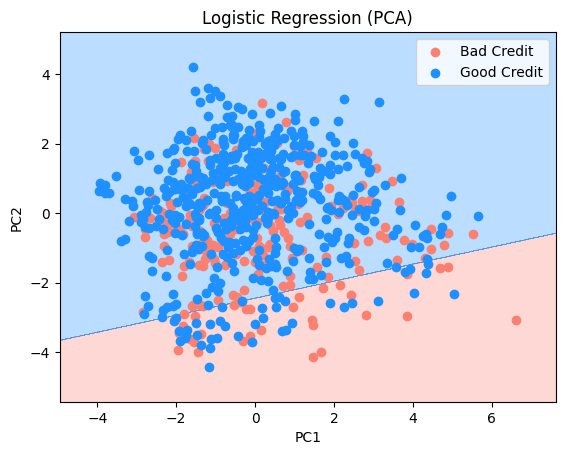

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)
plt.contourf(
    X1, X2,
    model_pca.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(['#FA8072', '#1E90FF'])
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(['#FA8072', '#1E90FF'])(i),
        label='Bad Credit' if j == 0 else 'Good Credit'
    )

plt.title('Logistic Regression (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend()
plt.show()

## hierarchical clustering

In [57]:
print(dataset.columns)

Index(['checking_account', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_account', 'employment_duration',
       'installment_rate', 'personal_status_sex', 'guarantor',
       'residence_duration', 'property', 'age', 'other_installment_plans',
       'housing', 'existing_credits', 'job', 'dependents', 'telephone',
       'foreign_worker', 'credit_risk'],
      dtype='object')


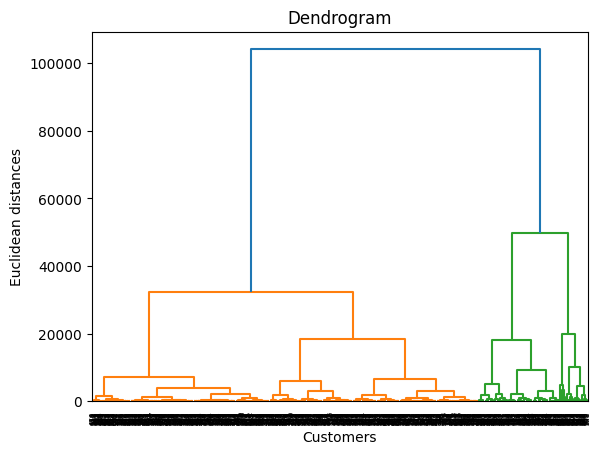

In [58]:

import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [59]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 2,metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

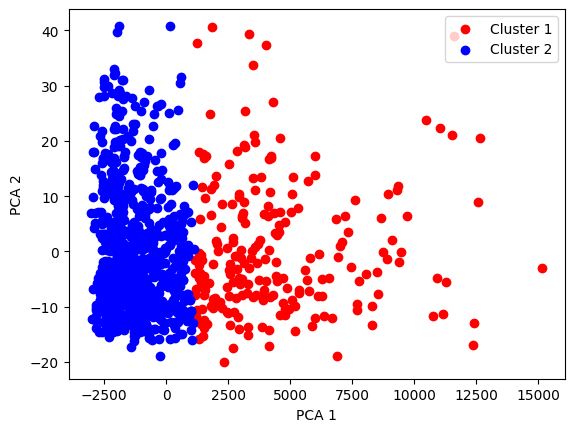

In [61]:
plt.scatter(X_pca[y_hc == 0, 0], X_pca[y_hc == 0, 1],
            c='red', label='Cluster 1')

plt.scatter(X_pca[y_hc == 1, 0], X_pca[y_hc == 1, 1],
            c='blue', label='Cluster 2')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

Clustering results show two distinct customer groups based on credit behavior.
PCA visualization confirms clear separation between clusters.